In [ ]:
"""
Gowalla DINModel. DONE

gowalla_DIN.ipynb
-> 把现成的样本文件读成 tensor
-> 用 DINTrain 训练一个“history + candidate -> score”模型
-> 评估时对所有 item 暴力打分取 top-k
"""

import torch
import numpy as np
import os, sys

sys.path.append("../..")    # 将仓库根目录加入Python模块搜索路径, 方便后续import lib

# ============= parametres =============#
data_set_name = "gowalla"   # 数据集
device = "cpu"              # device='cuda:0'
topk = 20                   # 推荐候选中取 top-k 评估
have_processed_data = True  # 是否跳过原始数据预处理, 直接读现成文件
emb_dim = 96                # item embedding 维度
sum_pooling = False         # 是否直接整体求和（False 表示按窗口分组聚合）
sample_negative_num = 60    # 每个正样本配 60 个随机负样本
feature_groups = [20, 20, 10, 10, 2, 2, 2, 1, 1, 1,]  # 定义模型如何处理历史序列. 69 个历史位置划分成 10 组
train_sample_seg_cnt = 10   # the training data is located in the train_sample_seg_cnt datafiles
parall = 10                 # 并行度. 用于data loader
seq_len = 70                # se_len-1 is the number of behaviours in all the windows, 每行样本的总长度(69 个历史 item + 1 个 label)
min_seq_len = 15            # 用户行为少于 15 条则丢弃
test_user_num = 6000        # the number of user in test file

# ============= data =============#
raw_data_file = "../../data/{}/{}.txt".format(data_set_name, data_set_name)             # 原始 Gowalla csv, 不存在. have_processed_data=True 时不走
train_instances_file = "../../data/{}/train_instances".format(data_set_name)            # 训练样本前缀
test_instances_file = "../../data/{}/test_instances".format(data_set_name)              # 测试样本
validation_instances_file = "../../data/{}/validation_instances".format(data_set_name)  # 验证样本
user_item_num_file = "../../data/{}/user_item_num.txt".format(data_set_name)            # 用户/物品数量
result_prefix = "../../data/result/DIN/"                                                # 结果前缀

training_batch_size = 256   # 训练 batch 大小
test_batch_size = 16        # 评估 batch 大小
batch_number = 50           # 总共训练步数. 原值80000

if device != "cpu":
    torch.cuda.set_device(device)
    device = "cuda"

# IPython magic. 加载自动重载扩展
%load_ext autoreload
# 模式2：每次执行cell前，自动重载所有变更过的模块
%autoreload 2

In [ ]:
import lib
from lib import generate_train_and_test_data
import gc
import numpy as np

# 原始数据预处理（不走）
if not have_processed_data:
    behavior_dict, train_sample, test_sample, val_sample, user_num, item_num = generate_train_and_test_data._read(raw_data_file, "train.dat", "test.dat", "validation.dat", test_user_num)
    # write the training instance into different train_sample_seg_cnt files， avoid that a file is too large
    # stat record the click frequency of each item
    # seq_len=20 min that 19 behaviors and one label
    stat = generate_train_and_test_data._gen_train_sample(
        train_sample,
        train_instances_file,
        test_sample=test_sample,
        val_sample=val_sample,
        train_sample_seg_cnt=train_sample_seg_cnt,
        parall=parall,
        seq_len=seq_len,
        min_seq_len=min_seq_len,
    )
    generate_train_and_test_data._gen_test_sample(test_sample, test_instances_file, seq_len=seq_len, min_seq_len=min_seq_len)
    del behavior_dict
    del train_sample
    del test_sample
    del stat
    np.savetxt(user_item_num_file, np.array([user_num, item_num]), fmt="%d", delimiter=",")
else:  # 直接读取现成文件（走）
    [user_num, item_num] = np.loadtxt(user_item_num_file, dtype=np.int32, delimiter=",")
print("user num is {}, item is {}".format(user_num, item_num))

user num is 13583, item is 71436


In [3]:
from lib import DINTrain

train_model = DINTrain(
    item_num=item_num,
    sample_negative_num=sample_negative_num,
    emb_dim=emb_dim,
    device=device,
    sum_pooling=sum_pooling,
    feature_groups=feature_groups,
)
print(train_model.DINModel)

DeepInterestNetwork(
  (item_embedding): EmbeddingLayer(
    (embed): Embedding(71437, 96, padding_idx=71436)
    (regularization): Dropout(p=0.1, inplace=False)
  )
  (attention_unit): LocalActivationUnit(
    (fc1): FullyConnectedLayer(
      (fc): Sequential(
        (0): Linear(in_features=384, out_features=64, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=64, out_features=16, bias=True)
        (4): ReLU()
        (5): Dropout(p=0.1, inplace=False)
      )
    )
    (fc2): FullyConnectedLayer(
      (fc): Sequential(
        (0): Linear(in_features=16, out_features=1, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc_layer): FullyConnectedLayer(
    (fc): Sequential(
      (0): Linear(in_features=1056, out_features=200, bias=True)
      (1): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=Fa

In [4]:
from pandas import DataFrame
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# 平滑训练曲线, 用于可视化
moving_average = lambda x, **kw: (
    DataFrame({"x": np.asarray(x)}).x.ewm(**kw).mean().values
)

train_loss_history = []         # train loss
train_precision_history = []    # train precision
train_recall_history = []       # train recall
train_f_measure_history = []    # train f_measure
train_novelty_history = []      # train novelty

test_precision_history = []     # test precision
test_recall_history = []        # test recall
test_f_measure_history = []     # test f_measure
test_novelty_history = []       # test novelty

In [ ]:
# 1. Precision（精确率）
# 推荐的结果里，有多少是用户真正喜欢的 -> 越高说明推荐越准
def precision(result_list, gt_list, top_k: int):
    """计算precision指标
    :param result_list: list of list, 每个list是一个用户的推荐结果, 已经处理为topK
    :param gt_list: list of list, 每个list是一个用户的真实点击结果
    :param top_k: int, 推荐结果的长度
    :return: float, precision指标的值
    """
    count = 0.0
    for r, g in zip(result_list, gt_list):
        count += 1.0 * len(set(r).intersection(set(g))) / top_k
    return count / len(result_list)


# 2. Recall（召回率）
# 用户喜欢的东西，有多少被你推荐出来了 -> 越高说明覆盖越全
def recall(result_list, gt_list):
    """计算recall指标
    :param result_list: list of list, 每个list是一个用户的推荐结果, 已经处理为topK
    :param gt_list: list of list, 每个list是一个用户的真实点击结果
    :return: float, recall指标的值
    """
    t = 0.0
    for r, g in zip(result_list, gt_list):
        t += 1.0 * len(set(r).intersection(set(g))) / len(g)
    return t / len(result_list)


# 3. F-measure（F1 分数）
# Precision + Recall 的综合分数 -> 越高说明整体效果越好
def f_measure(result_list, gt_list, top_k, eps=1.0e-9):
    """计算f_measure指标
    :param result_list: list of list, 每个list是一个用户的推荐结果, 已经处理为topK
    :param gt_list: list of list, 每个list是一个用户的真实点击结果
    :param top_k: int, 推荐结果的长度
    :param eps: float, 防止除零的极小值
    :return: float, f_measure指标的值
    """
    f = 0.0
    for r, g in zip(result_list, gt_list):
        precision = 1.0 * len(set(r).intersection(set(g))) / top_k
        recall = 1.0 * len(set(r).intersection(set(g))) / len(g)
        if recall + precision < eps:
            continue
        f += (2 * recall * precision) / (recall + precision)
    return f / len(result_list)


# 4. Novelty（新颖度）
# 推荐结果的多样性 / 新奇度 -> 越高说明推荐不重复、不单调
def novelty(result_list, s_u, top_k):
    """计算novelty指标
    :param result_list: list of list, 每个list是一个用户的推荐结果, 已经处理为topK
    :param s_u: list of list, 每个list是一个用户的历史点击结果
    :param top_k: int, 推荐结果的长度
    :return: float, novelty指标的值
    """
    count = 0.0
    for r, g in zip(result_list, s_u):
        count += 1.0 * len(set(r) - set(g)) / top_k
    return count / len(result_list)


def hit_ratio(result_list, gt_list):
    """计算hit_ratio指标
    :param result_list: list of list, 每个list是一个用户的推荐结果
    :param gt_list: list of list, 每个list是一个用户的真实点击结果
    :return: float, hit_ratio指标的值
    """
    intersect_set = [len(set(r) & set(g)) for r, g in zip(result_list, gt_list)]
    return 1.0 * sum(intersect_set) / sum([len(gts) for gts in gt_list])


def NDCG(result_list, gt_list):
    """计算NDCG指标
    :param result_list: list of list, 每个list是一个用户的推荐结果
    :param gt_list: list of list, 每个list是一个用户的真实点击结果
    :return: float, NDCG指标的值
    """
    t = 0.0
    for re, gt in zip(result_list, gt_list):
        setgt = set(gt)
        indicator = np.asfarray([1 if r in setgt else 0 for r in re])
        sorted_indicator = np.ones(min(len(setgt), len(re)))
        if 1 in indicator:
            t += np.sum(
                indicator / np.log2(1.0 * np.arange(2, len(indicator) + 2))
            ) / np.sum(
                sorted_indicator
                / np.log2(1.0 * np.arange(2, len(sorted_indicator) + 2))
            )
    return t / len(gt_list)


def MAP(result_list, gt_list, topk):
    """计算MAP指标
    :param result_list: list of list, 每个list是一个用户的推荐结果
    :param gt_list: list of list, 每个list是一个用户的真实点击结果
    :param topk: int, 推荐结果的长度
    :return: float, MAP指标的值
    """
    t = 0.0
    for re, gt in zip(result_list, gt_list):
        setgt = set(gt)
        indicator = np.asfarray([1 if r in setgt else 0 for r in re])
        t += np.mean([indicator[:i].sum(-1) / i for i in range(1, topk + 1)], axis=-1)
    return t / len(gt_list)

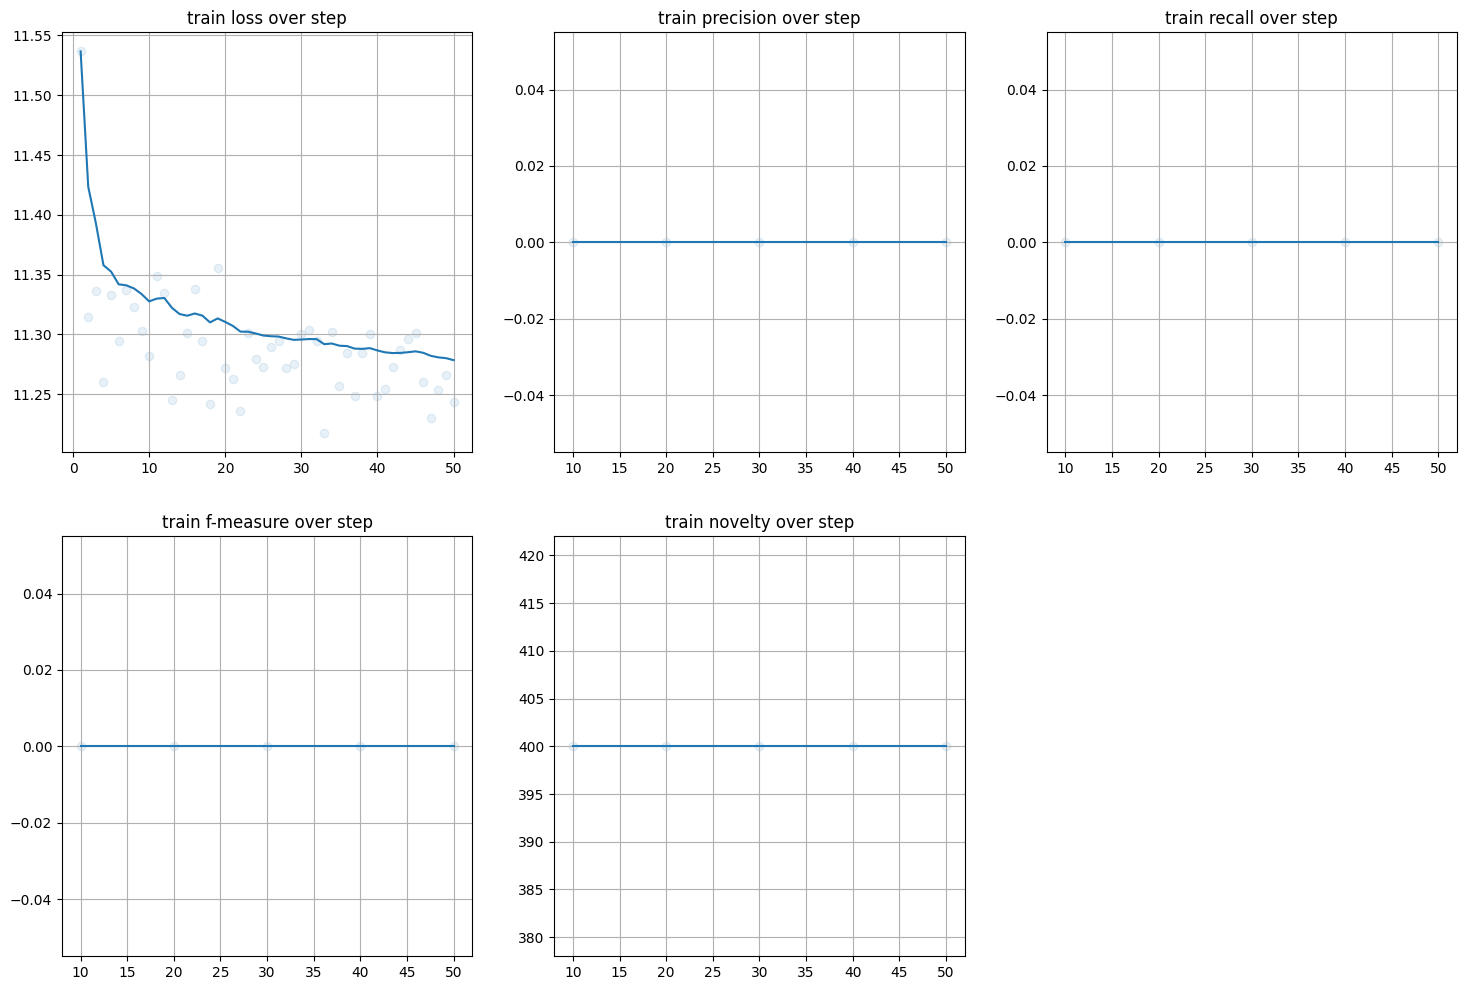

step=50, mean_loss=11.290, time=1.000
____________________________________________________________________________________________________
train_model.batch_num: 50


In [8]:
# train_model.DINModel.train()

from lib.generate_training_batches import Train_instance
from typing import Generator

train_instances: Train_instance = Train_instance(parall=parall)

### train Generator
# 方式1: 每轮训练都重新读所有文件！
# training_batch_generator: Generator = train_instances.training_batches(
#     train_instances_file,
#     train_sample_seg_cnt,
#     item_num,
#     batchsize=training_batch_size
# )

# 方式2: 只读一次文件 → 全程内存跑 → 无限循环生成batch → 训练最快最稳！
training_data, training_labels = train_instances.get_training_data(
    train_instances_file, train_sample_seg_cnt, item_num
)
train_batch_generator: Generator = train_instances.generate_training_records(
    training_data, training_labels, batch_size=training_batch_size
)

### validation Generator
validation_batch_generator: Generator = train_instances.validation_batches(
    validation_instances_file, item_num, batchsize=test_batch_size
)

### test Generator
test_batch_generator: Generator = train_instances.test_batches(
    test_instances_file, item_num, batchsize=test_batch_size
)

# 训练循环
for batch_x, batch_y in train_batch_generator:
    # print(batch_x, batch_y)
    print(f"train_model.batch_num: {train_model.batch_num}")
    loss = train_model.update_DIN(batch_x, batch_y)
    train_loss_history.append(loss.item())

    # 每 10 step, 全量暴力验证 + 画图
    if train_model.batch_num % 10 == 0:
        ### start to validation ###
        val_batch, val_index = validation_batch_generator.__next__()
        scores: np.ndarray = train_model.predict_for_user(val_batch, topk=topk)
        _, result_history = torch.topk(scores, k=topk, dim=-1)
        gt_history: list[int] = [train_instances.validation_labels[i.item()] for i in val_index]

        train_precision_history.append(precision(result_history, gt_history, topk))     # precision
        train_recall_history.append(recall(result_history, gt_history))                 # recall
        train_f_measure_history.append(f_measure(result_history, gt_history, topk))     # f_measure
        train_novelty_history.append(novelty(result_history, val_batch.tolist(), topk)) # novelty
        #######

        clear_output(True)
        plt.figure(figsize=[18, 12])

        plt.subplot(2, 3, 1)
        plt.title("train loss over step")
        plt.grid()
        steps = np.arange(1, len(train_loss_history) + 1)
        plt.plot(steps, moving_average(train_loss_history, span=50))
        plt.scatter(steps, train_loss_history, alpha=0.1)

        plt.subplot(2, 3, 2)
        plt.title("train precision over step")
        plt.grid()
        steps = np.arange(10, 10 * len(train_precision_history) + 1, 10)
        plt.plot(steps, moving_average(train_precision_history, span=50))
        plt.scatter(steps, train_precision_history, alpha=0.1)

        plt.subplot(2, 3, 3)
        plt.title("train recall over step")
        plt.grid()
        steps = np.arange(10, 10 * len(train_recall_history) + 1, 10)
        plt.plot(steps, moving_average(train_recall_history, span=10))
        plt.scatter(steps, train_recall_history, alpha=0.1)

        plt.subplot(2, 3, 4)
        plt.title("train f-measure over step")
        plt.grid()
        steps = np.arange(10, 10 * len(train_f_measure_history) + 1, 10)
        plt.plot(steps, moving_average(train_f_measure_history, span=10))
        plt.scatter(steps, train_f_measure_history, alpha=0.1)

        plt.subplot(2, 3, 5)
        plt.title("train novelty over step")
        plt.grid()
        steps = np.arange(10, 10 * len(train_novelty_history) + 1, 10)
        plt.plot(steps, moving_average(train_novelty_history, span=10))
        plt.scatter(steps, train_novelty_history, alpha=0.1)

        plt.show()
        print("step=%i, mean_loss=%.3f, time=%.3f" % (len(train_loss_history), np.mean(train_loss_history[-100:]), 1.0))
        print("_" * 100)

    # 训练结束, 保存结果
    if train_model.batch_num > batch_number:
        np.savetxt(result_prefix + "prob_train_loss.txt", np.array(train_loss_history), fmt="%f",)
        np.savetxt(result_prefix + "prob_train_precision.txt", np.array(train_precision_history), fmt="%f",)
        np.savetxt(result_prefix + "prob_train_recall.txt", np.array(train_recall_history), fmt="%f",)
        np.savetxt(result_prefix + "prob_train_f_measure.txt", np.array(train_f_measure_history), fmt="%f",)
        np.savetxt(result_prefix + "prob_train_novelty.txt", np.array(train_novelty_history), fmt="%f",)
        break

In [9]:
# 测试阶段
# 在测试集上做全量 TOP-K 推荐, 计算评估指标
test_instances: torch.Tensor = train_instances.read_test_instances_file(test_instances_file, item_num)

scores: torch.Tensor = train_model.predict_for_user(test_instances, topk=topk)
_, result_history = torch.topk(scores, k=topk, dim=-1)
result_history = result_history.numpy()
print(result_history[:2])
print(train_instances.test_labels[:2])

test_precision_history.append(precision(result_history, train_instances.test_labels, topk))
test_recall_history.append(recall(result_history, train_instances.test_labels))
test_f_measure_history.append(f_measure(result_history, train_instances.test_labels, topk))
test_novelty_history.append(novelty(result_history, test_instances.tolist(), topk))

KeyboardInterrupt: 

In [ ]:
DIN_Model_path = "../../data/{}/DIN_MODEL.pt".format(data_set_name)

# 保存整个模型
torch.save(train_model.DINModel, DIN_Model_path)

# 打印评估的4个核心指标
print(
    test_precision_history[-1],  # 精确率
    test_recall_history[-1],  # 召回率
    test_f_measure_history[-1],  # F1值（综合指标）
    test_novelty_history[-1],  # 新颖度
)


In [ ]:
sorted_test_users_path = "../../data/{}/sorted_test_users.txt".format(data_set_name)
np.savetxt(sorted_test_users_path, scores.argsort(dim=-1).numpy(), delimiter=",", fmt="%d")

In [ ]:
from lib.generate_training_batches import Train_instance

train_instances = Train_instance(parall=parall)
test_instances = train_instances.read_test_instances_file(test_instances_file, item_num)

sorted_test_users_path = "../../data/{}/sorted_test_users.txt".format(data_set_name)
scores = np.loadtxt(sorted_test_users_path, delimiter=",")

In [ ]:
topk = 40
# result_history = scores.argsort(dim=-1)[:, -topk:].numpy()
_, result_history = torch.topk(scores, k=topk, dim=-1).values
gt_history = train_instances.test_labels

precision = precision(result_history, gt_history, topk)
recall = recall(result_history, gt_history)
f1 = f_measure(result_history, gt_history, topk)
novelty = novelty(result_history, test_instances.tolist(), topk)
hit_rate = hit_ratio(result_history, gt_history)
ndcg = NDCG(result_history, gt_history)
map = MAP(result_history, gt_history, topk)

print("{:.4f}   {:.4f}   {:.4f}   {:.4f}   {:.4f}   {:.4f}   {:.4f}".format(precision, recall, f1, novelty, hit_rate, ndcg, map))

In [ ]:
np.array(scores, dtype=np.int32)
